### Dataset Description

The **NSL-KDD** dataset is an improved version of the original 1999 KDD Cup dataset, created to
address known issues (duplicate records, biased class distributions) in the older dataset. It
contains network connection records, each described by 41 features (e.g. connection duration,
protocol type, service, byte counts, error rates) plus a label identifying the connection as
either **normal** traffic or one of several **attack** types (grouped into DoS, Probe, R2L, and
U2R categories).

The classification goal is to predict whether a given connection is normal or an intrusion
(variable `label`), and this notebook compares four models for that task: **Logistic Regression**,
**Random Forest**, **XGBoost**, and **SVM**.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

In [3]:
df=pd.read_csv("KDDTrain+.txt")

In [4]:
df.shape

(125972, 43)

#### Data Preprocessing & Exploratory Data Analysis (EDA)

In [5]:
COLUMN_NAMES = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted",
    "num_root", "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty"
]

In [6]:
df = pd.read_csv("KDDTrain+.txt", header=None, names=COLUMN_NAMES)

In [7]:
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,21
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,18
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,20


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [9]:
#String columns
print(df.select_dtypes(include="object").columns)

Index(['protocol_type', 'service', 'flag', 'label'], dtype='str')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17660\1181284026.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include="object").columns)


In [10]:
#Unique values in label column
df['label'].unique()

<StringArray>
[         'normal',         'neptune',     'warezclient',         'ipsweep',
       'portsweep',        'teardrop',            'nmap',           'satan',
           'smurf',             'pod',            'back',    'guess_passwd',
       'ftp_write',        'multihop',         'rootkit', 'buffer_overflow',
            'imap',     'warezmaster',             'phf',            'land',
      'loadmodule',             'spy',            'perl']
Length: 23, dtype: str

In [11]:
#Copy of df
df_copy=df.copy()

In [12]:
#Sum of null values in df_copy
df_copy.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [13]:
#Sum of duplicate values
df_copy.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [15]:
df["label"].value_counts()

label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

In [16]:
df["label"].value_counts(normalize=True) * 100

label
normal             53.458281
neptune            32.716534
satan               2.883951
ipsweep             2.856961
portsweep           2.326689
smurf               2.100450
nmap                1.185175
back                0.758893
teardrop            0.708088
warezclient         0.706501
pod                 0.159558
guess_passwd        0.042073
buffer_overflow     0.023815
warezmaster         0.015876
land                0.014289
imap                0.008732
rootkit             0.007938
loadmodule          0.007144
ftp_write           0.006351
multihop            0.005557
phf                 0.003175
perl                0.002381
spy                 0.001588
Name: proportion, dtype: float64

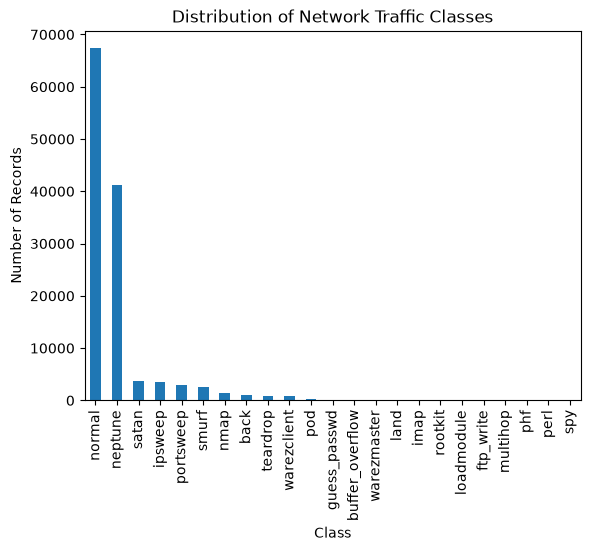

In [17]:
#Categorical attributes
df["label"].value_counts().plot(kind="bar")

plt.title("Distribution of Network Traffic Classes")
plt.xlabel("Class")
plt.ylabel("Number of Records")
plt.xticks(rotation=90)
plt.show()

In [18]:
##it shows data is imbalanced

Normal
normal
DoS attacks

Examples:

neptune
smurf
back
teardrop
pod
Probe attacks

Examples:

satan
ipsweep
portsweep
nmap
R2L attacks

Examples:

warezclient
guess_passwd
ftp_write
imap
U2R attacks

Examples:

buffer_overflow
rootkit
loadmodule
perl

So the individual labels are not random values. They represent different types of network attacks.

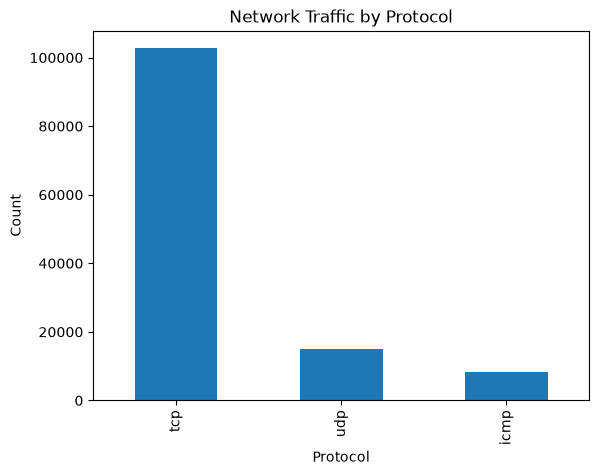

In [19]:
df["protocol_type"].value_counts().plot(kind="bar")

plt.title("Network Traffic by Protocol")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.show()

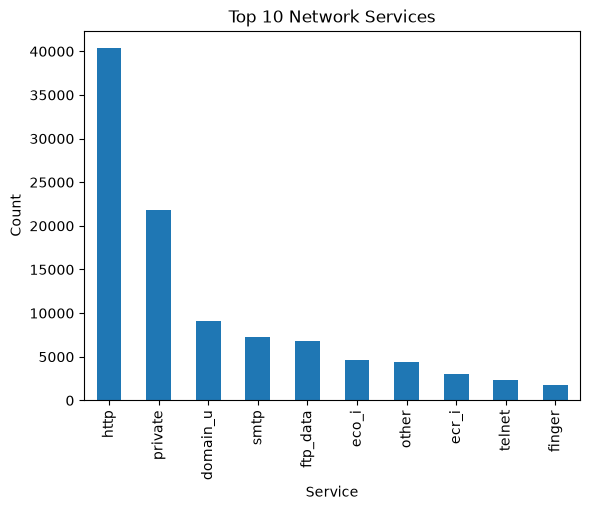

In [20]:
df["service"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Network Services")
plt.xlabel("Service")
plt.ylabel("Count")
plt.show()

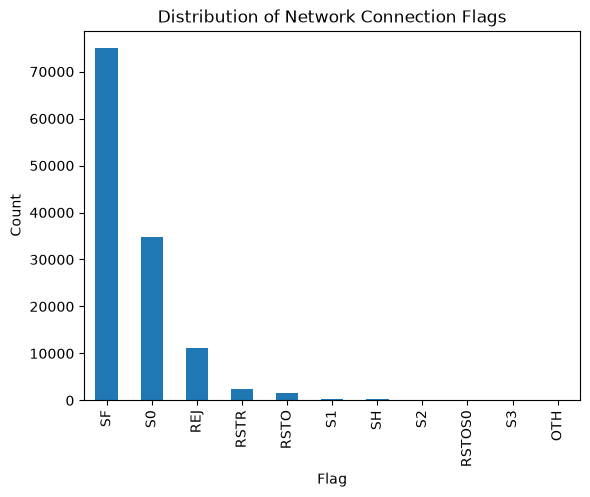

In [21]:
df["flag"].value_counts().plot(kind="bar")

plt.title("Distribution of Network Connection Flags")
plt.xlabel("Flag")
plt.ylabel("Count")
plt.show()

In [22]:
#Binary labeling
df["binary_label"] = df["label"].apply(
    lambda x: "normal" if x == "normal" else "attack"
)

In [23]:
df["binary_label"].value_counts()

binary_label
normal    67343
attack    58630
Name: count, dtype: int64

In [24]:
#Cleaning the label attribute
df["label"] = df["label"].str.strip().str.lower()

In [25]:
df["label"].unique()

<StringArray>
[         'normal',         'neptune',     'warezclient',         'ipsweep',
       'portsweep',        'teardrop',            'nmap',           'satan',
           'smurf',             'pod',            'back',    'guess_passwd',
       'ftp_write',        'multihop',         'rootkit', 'buffer_overflow',
            'imap',     'warezmaster',             'phf',            'land',
      'loadmodule',             'spy',            'perl']
Length: 23, dtype: str

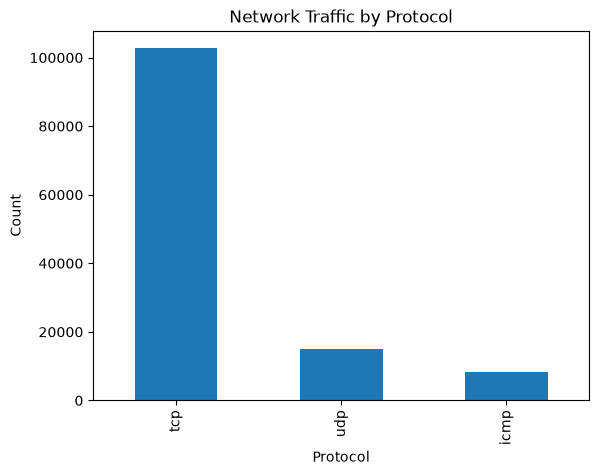

In [26]:
df["protocol_type"].value_counts().plot(kind="bar")

plt.title("Network Traffic by Protocol")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.show()

### Boxplots for duration, source bytes, destination bytes, num_failed_logins, num_compromised

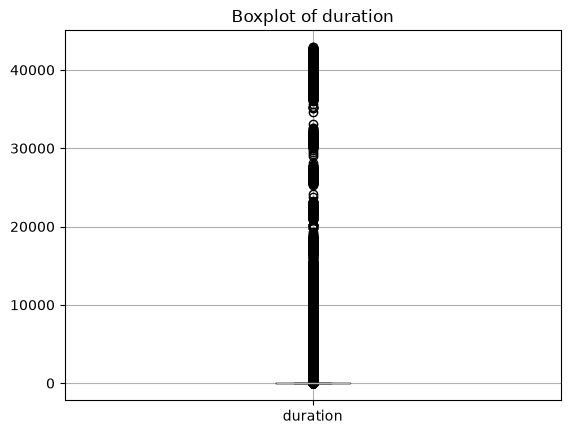

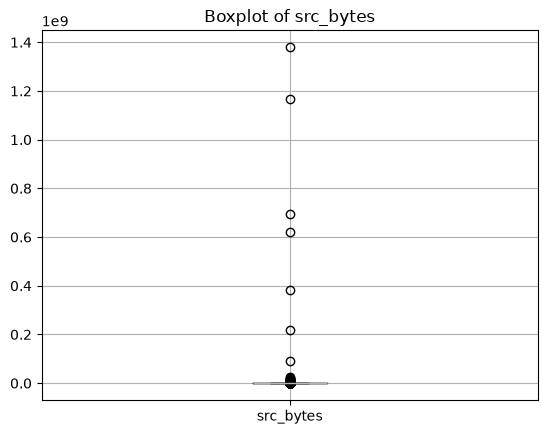

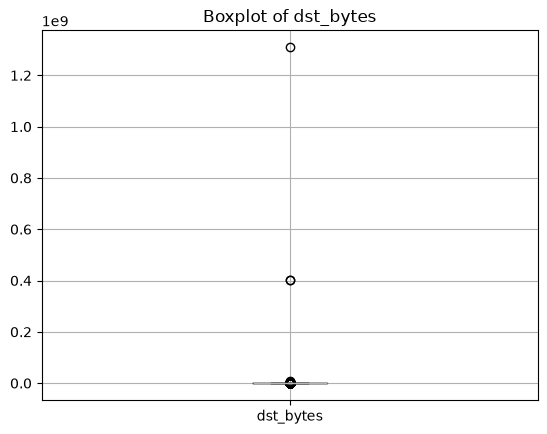

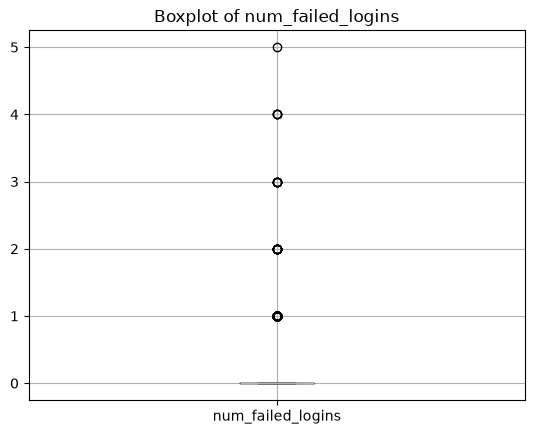

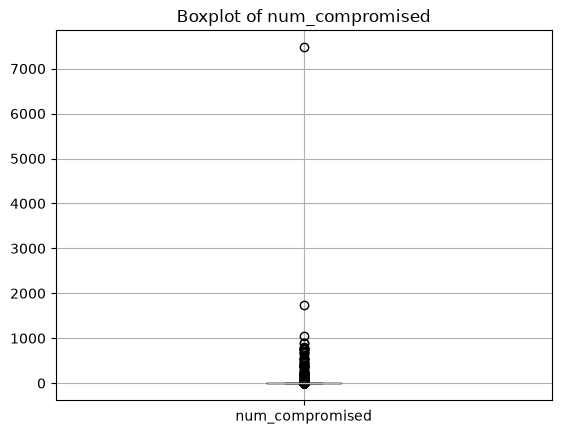

In [27]:
def box_plot(attribute):
    df[[attribute]].boxplot()
    plt.title(f"Boxplot of {attribute}")
    plt.show()

numeric_cols = [
    'duration', 'src_bytes', 'dst_bytes', 'num_failed_logins', 'num_compromised'
]

for col in numeric_cols:
    box_plot(col)


In [28]:
df["src_bytes"].describe()

count    1.259730e+05
mean     4.556674e+04
std      5.870331e+06
min      0.000000e+00
25%      0.000000e+00
50%      4.400000e+01
75%      2.760000e+02
max      1.379964e+09
Name: src_bytes, dtype: float64

Since the amount of data is very large, the box plots are compressed. To fix this issue, logarithm box plot is performed on Source Bytes and Destination Bytes.

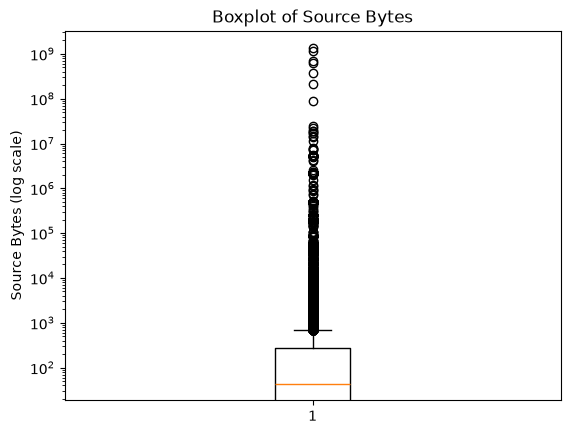

In [29]:
plt.boxplot(df["src_bytes"])

plt.yscale("log")

plt.title("Boxplot of Source Bytes")
plt.ylabel("Source Bytes (log scale)")
plt.show()

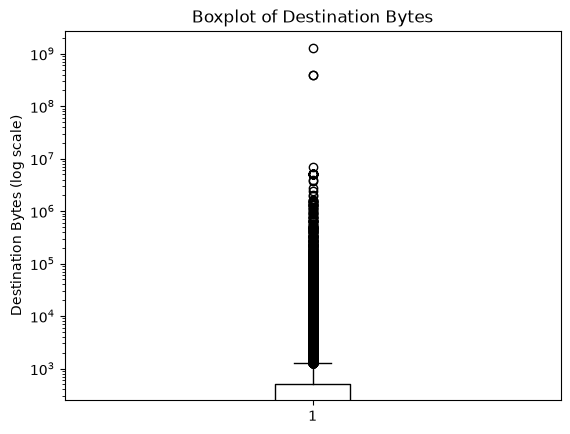

In [30]:
plt.boxplot(df["dst_bytes"])

plt.yscale("log")

plt.title("Boxplot of Destination Bytes")
plt.ylabel("Destination Bytes (log scale)")
plt.show()

### Bar Graph for duration, num_failed_logins, and num_compromised

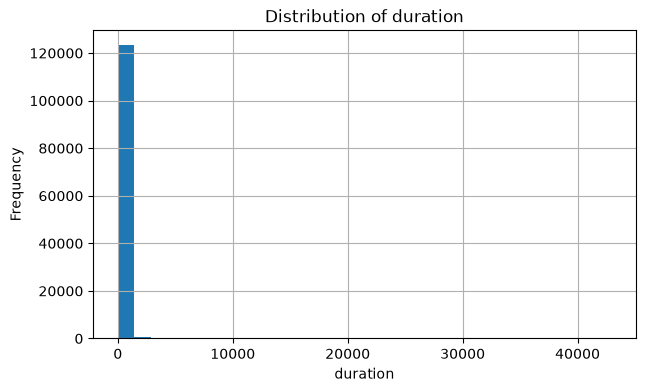

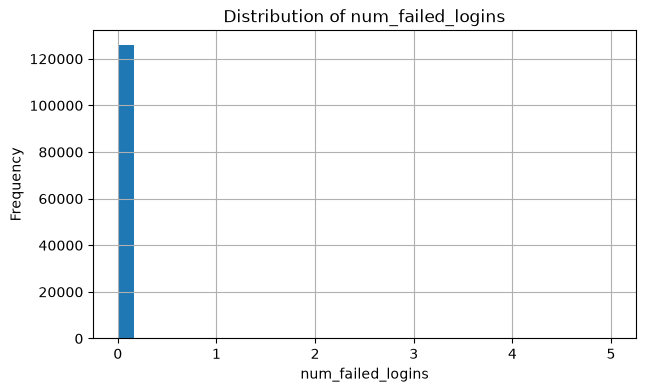

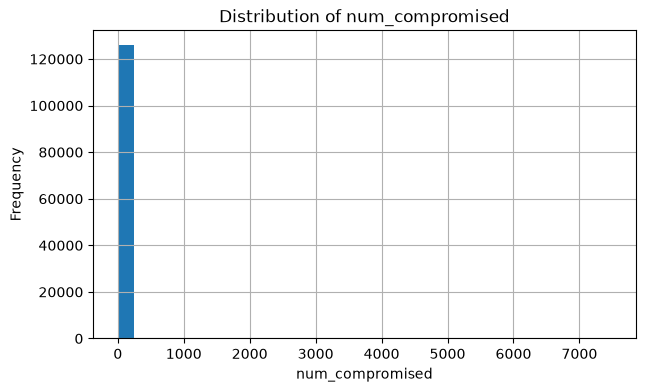

In [31]:
cols = ['duration', 'num_failed_logins', 'num_compromised']

for col in cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col], bins=30)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.grid(True)
    plt.show()

In [32]:
#Convert categorical features to category dtype
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17660\2891593083.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [33]:
#This tells us what categories exist and how many records belong to each.
categorical_cols = ['protocol_type', 'service', 'flag']

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


protocol_type:
protocol_type
tcp     102689
udp      14993
icmp      8291
Name: count, dtype: int64

service:
service
http         40338
private      21853
domain_u      9043
smtp          7313
ftp_data      6860
             ...  
tftp_u           3
aol              2
harvest          2
http_8001        2
http_2784        1
Name: count, Length: 70, dtype: int64

flag:
flag
SF        74945
S0        34851
REJ       11233
RSTR       2421
RSTO       1562
S1          365
SH          271
S2          127
RSTOS0      103
S3           49
OTH          46
Name: count, dtype: int64


### Bar Graph for categorical values (protocol_type, service, flag)

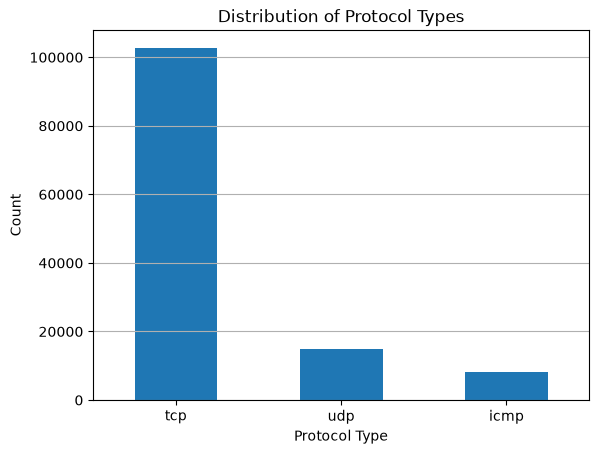

In [34]:
import matplotlib.pyplot as plt

df['protocol_type'].value_counts().plot(kind='bar')

plt.xlabel('Protocol Type')
plt.ylabel('Count')
plt.title('Distribution of Protocol Types')
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.show()

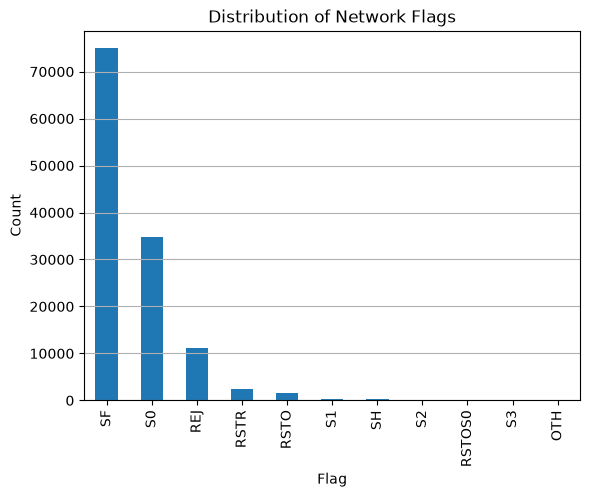

In [35]:
### for flag
df['flag'].value_counts().plot(kind='bar')

plt.xlabel('Flag')
plt.ylabel('Count')
plt.title('Distribution of Network Flags')
plt.grid(axis='y')
plt.show()

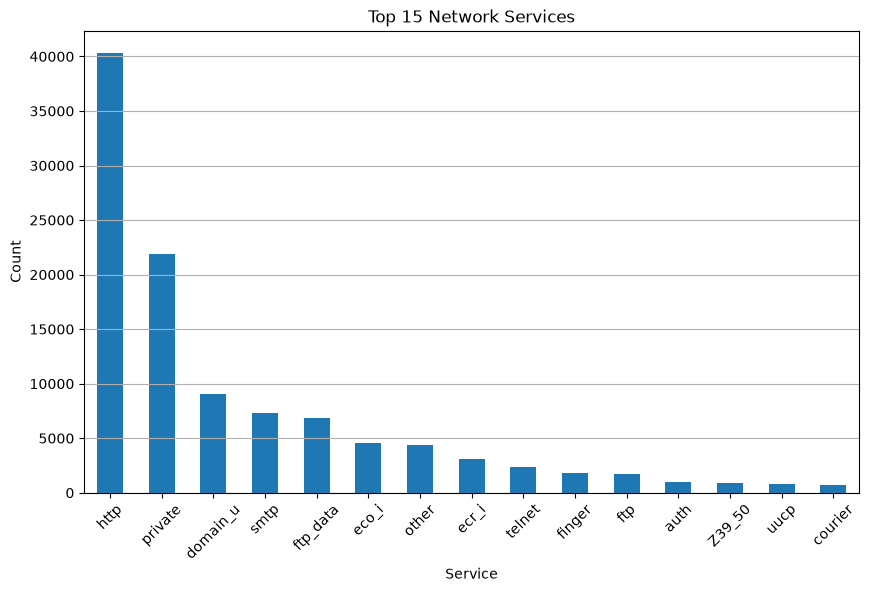

In [36]:
#Distribution of top 15 Network Services
service_counts = df['service'].value_counts()

top_services = service_counts.head(15)

plt.figure(figsize=(10, 6))
top_services.plot(kind='bar')

plt.xlabel('Service')
plt.ylabel('Count')
plt.title('Top 15 Network Services')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

##### Numerical Attributes

In [37]:
numeric_cols = [
    'duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count',
    'serror_rate', 'same_srv_rate', 'dst_host_count', 'dst_host_srv_count'
]

### Correlation Heatmap  of Numerical Features

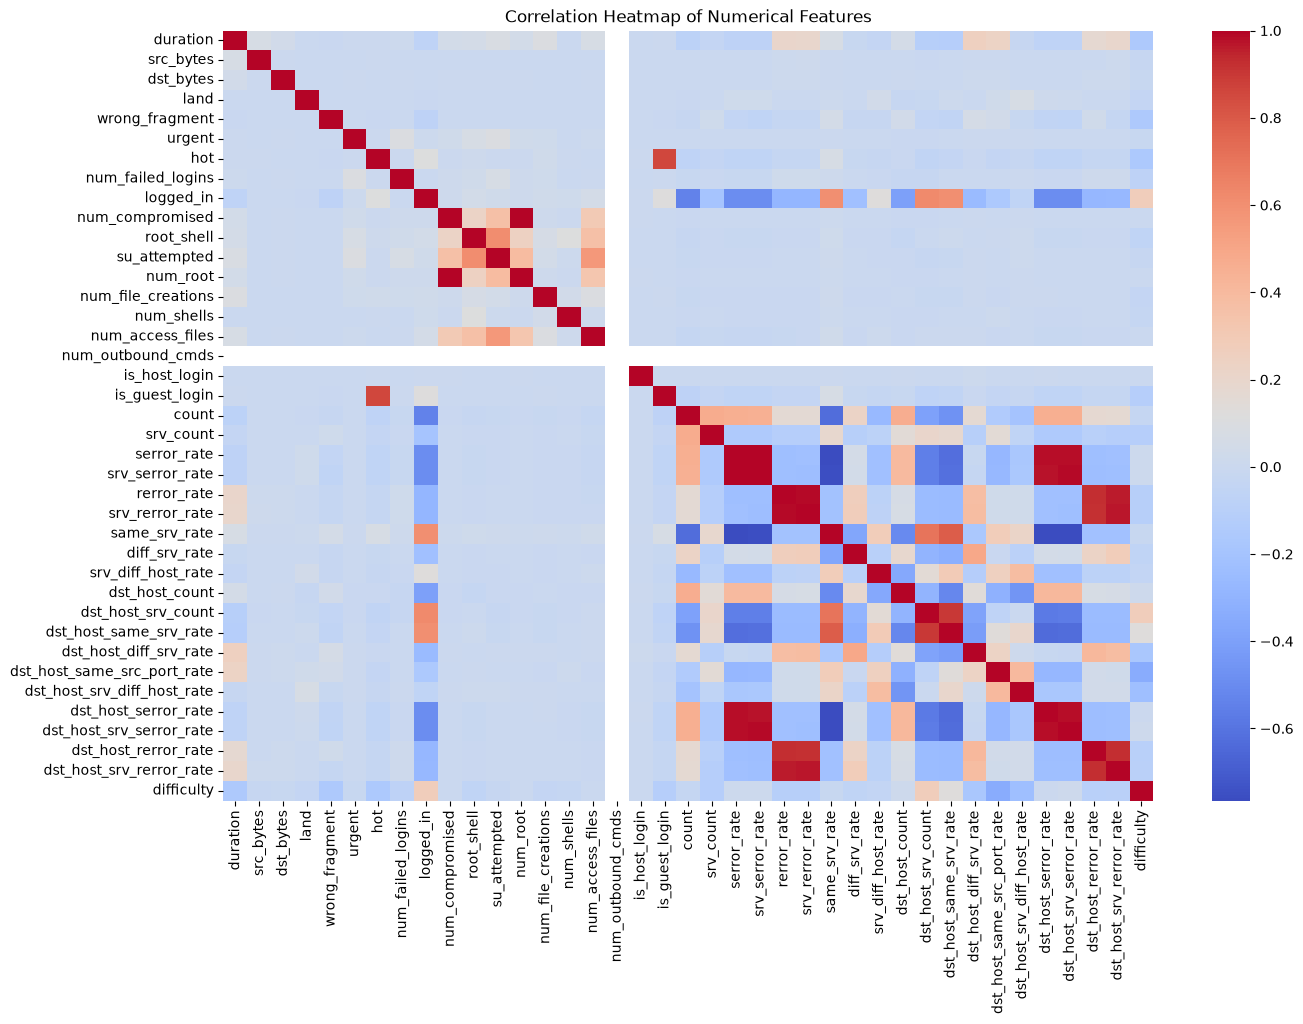

In [38]:
# Select only numerical columns
numeric_df = df.select_dtypes(include='number')

# Calculate correlation
corr = numeric_df.corr()

# Draw heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm')

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

### Correlation Heatmap of selected_cols from numeric_cols

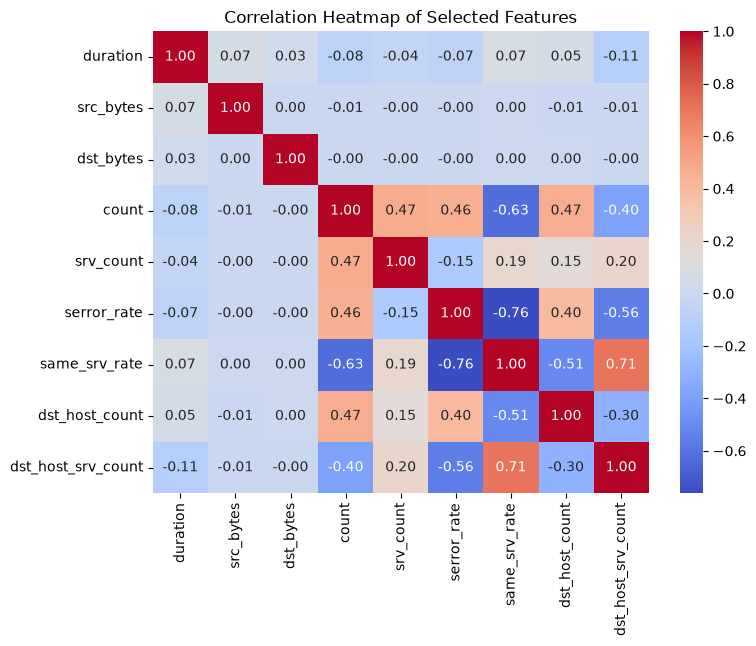

In [39]:
selected_cols = [
    'duration',
    'src_bytes',
    'dst_bytes',
    'count',
    'srv_count',
    'serror_rate',
    'same_srv_rate',
    'dst_host_count',
    'dst_host_srv_count',
   
]

corr = df[selected_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap of Selected Features")
plt.show()

#'num_failed_logins', 'num_compromised'

### Drop difficulty column

In [40]:
df = df.drop(columns=["difficulty"])

In [41]:
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,binary_label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,attack
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125968,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.06,0.00,0.00,1.00,1.00,0.00,0.00,neptune,attack
125969,8,udp,private,SF,105,145,0,0,0,0,...,0.96,0.01,0.01,0.00,0.00,0.00,0.00,0.00,normal,normal
125970,0,tcp,smtp,SF,2231,384,0,0,0,0,...,0.12,0.06,0.00,0.00,0.72,0.00,0.01,0.00,normal,normal
125971,0,tcp,klogin,S0,0,0,0,0,0,0,...,0.03,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,attack


In [42]:
# binary label from string to integer
df["binary_label"] = (df["label"] != "normal").astype(int)  # 0 = normal, 1 = attack

In [43]:
# Label encoding categorical data
encoders = {}
for col in ["protocol_type", "service", "flag"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

### Preprocessing for Test Data

In [44]:
df2 = pd.read_csv("KDDTest+.txt")

In [45]:
df2.shape

(22543, 43)

In [46]:
COLUMN_NAMES = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted",
    "num_root", "num_file_creations", "num_shells", "num_access_files",
    "num_outbound_cmds", "is_host_login", "is_guest_login", "count",
    "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate",
    "label", "difficulty"
]

In [47]:
df2 = pd.read_csv("KDDTest+.txt", header=None, names=COLUMN_NAMES)

In [48]:
df2

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,mscan,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00,normal,21
22540,0,tcp,http,SF,317,938,0,0,0,0,...,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00,normal,21
22541,0,tcp,http,SF,54540,8314,0,0,0,2,...,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07,back,15
22542,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00,normal,21


In [49]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     22544 non-null  int64  
 1   protocol_type                22544 non-null  str    
 2   service                      22544 non-null  str    
 3   flag                         22544 non-null  str    
 4   src_bytes                    22544 non-null  int64  
 5   dst_bytes                    22544 non-null  int64  
 6   land                         22544 non-null  int64  
 7   wrong_fragment               22544 non-null  int64  
 8   urgent                       22544 non-null  int64  
 9   hot                          22544 non-null  int64  
 10  num_failed_logins            22544 non-null  int64  
 11  logged_in                    22544 non-null  int64  
 12  num_compromised              22544 non-null  int64  
 13  root_shell                 

In [50]:
#String columns
print(df2.select_dtypes(include="object").columns)

Index(['protocol_type', 'service', 'flag', 'label'], dtype='str')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17660\1526888999.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df2.select_dtypes(include="object").columns)


In [51]:
#Unique values in label column
df2['label'].unique()

<StringArray>
[        'neptune',          'normal',           'saint',           'mscan',
    'guess_passwd',           'smurf',         'apache2',           'satan',
 'buffer_overflow',            'back',     'warezmaster',   'snmpgetattack',
    'processtable',             'pod',      'httptunnel',            'nmap',
              'ps',       'snmpguess',         'ipsweep',        'mailbomb',
       'portsweep',        'multihop',           'named',        'sendmail',
      'loadmodule',           'xterm',            'worm',        'teardrop',
         'rootkit',           'xlock',            'perl',            'land',
          'xsnoop',       'sqlattack',       'ftp_write',            'imap',
        'udpstorm',             'phf']
Length: 38, dtype: str

In [52]:
#Unique values in service column
df2['service'].unique()

<StringArray>
[    'private',    'ftp_data',       'eco_i',      'telnet',        'http',
        'smtp',         'ftp',        'ldap',       'pop_3',     'courier',
     'discard',       'ecr_i',       'imap4',    'domain_u',         'mtp',
      'systat',    'iso_tsap',       'other',    'csnet_ns',      'finger',
        'uucp',       'whois',  'netbios_ns',        'link',      'Z39_50',
      'sunrpc',        'auth', 'netbios_dgm',   'uucp_path',       'vmnet',
      'domain',        'name',       'pop_2',    'http_443',       'urp_i',
       'login',      'gopher',        'exec',        'time',  'remote_job',
         'ssh',      'kshell',     'sql_net',       'shell',   'hostnames',
        'echo',     'daytime',     'pm_dump',         'IRC',     'netstat',
         'ctf',        'nntp', 'netbios_ssn',       'tim_i',      'supdup',
         'bgp',        'nnsp',         'rje',     'printer',         'efs',
         'X11',       'ntp_u',      'klogin',      'tftp_u']
Length: 64, d

In [53]:
df2.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [54]:
df2.duplicated().sum()

np.int64(0)

In [55]:
df2.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,22544.000000,2.254400e+04,2.254400e+04,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,...,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000,22544.000000
mean,218.859076,1.039545e+04,2.056019e+03,0.000311,0.008428,0.000710,0.105394,0.021647,0.442202,0.119899,...,140.750532,0.608722,0.090540,0.132261,0.019638,0.097814,0.099426,0.233385,0.226683,18.017965
std,1407.176612,4.727864e+05,2.121930e+04,0.017619,0.142599,0.036473,0.928428,0.150328,0.496659,7.269597,...,111.783972,0.435688,0.220717,0.306268,0.085394,0.273139,0.281866,0.387229,0.400875,4.270361
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,15.000000,0.070000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000
50%,0.000000,5.400000e+01,4.600000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,168.000000,0.920000,0.010000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.000000,2.870000e+02,6.010000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.060000,0.030000,0.010000,0.000000,0.000000,0.360000,0.170000,21.000000
max,57715.000000,6.282565e+07,1.345927e+06,1.000000,3.000000,3.000000,101.000000,4.000000,1.000000,796.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [56]:
df2["label"].value_counts()

label
normal             9711
neptune            4657
guess_passwd       1231
mscan               996
warezmaster         944
apache2             737
satan               735
processtable        685
smurf               665
back                359
snmpguess           331
saint               319
mailbomb            293
snmpgetattack       178
portsweep           157
ipsweep             141
httptunnel          133
nmap                 73
pod                  41
buffer_overflow      20
multihop             18
named                17
ps                   15
sendmail             14
xterm                13
rootkit              13
teardrop             12
xlock                 9
land                  7
xsnoop                4
ftp_write             3
loadmodule            2
worm                  2
perl                  2
sqlattack             2
udpstorm              2
phf                   2
imap                  1
Name: count, dtype: int64

In [57]:
#Binary labeling
df2["binary_label"] = df2["label"].apply(
    lambda x: "normal" if x == "normal" else "attack"
)

In [58]:
df2["binary_label"].value_counts()

binary_label
attack    12833
normal     9711
Name: count, dtype: int64

In [59]:
#Cleaning the label attribute
df2["label"] = df2["label"].str.strip().str.lower()

In [60]:
df2["label"].unique()

<StringArray>
[        'neptune',          'normal',           'saint',           'mscan',
    'guess_passwd',           'smurf',         'apache2',           'satan',
 'buffer_overflow',            'back',     'warezmaster',   'snmpgetattack',
    'processtable',             'pod',      'httptunnel',            'nmap',
              'ps',       'snmpguess',         'ipsweep',        'mailbomb',
       'portsweep',        'multihop',           'named',        'sendmail',
      'loadmodule',           'xterm',            'worm',        'teardrop',
         'rootkit',           'xlock',            'perl',            'land',
          'xsnoop',       'sqlattack',       'ftp_write',            'imap',
        'udpstorm',             'phf']
Length: 38, dtype: str

In [61]:
#Convert categorical features to category dtype
for col in df2.select_dtypes(include='object').columns:
    df2[col] = df2[col].astype('category')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_17660\2406103586.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df2.select_dtypes(include='object').columns:


In [62]:
#This tells us what categories exist and how many records belong to each.
categorical_cols = ['protocol_type', 'service', 'flag']

for col in categorical_cols:
    print(f"\n{col}:")
    print(df2[col].value_counts())


protocol_type:
protocol_type
tcp     18880
udp      2621
icmp     1043
Name: count, dtype: int64

service:
service
http       7853
private    4774
telnet     1626
pop_3      1019
smtp        934
           ... 
printer      11
ntp_u        10
rje           8
tim_i         6
tftp_u        1
Name: count, Length: 64, dtype: int64

flag:
flag
SF        14875
REJ        3850
S0         2013
RSTO        773
RSTR        669
S3          249
SH           73
S1           21
S2           15
OTH           4
RSTOS0        2
Name: count, dtype: int64


In [63]:
numeric_cols = [
    'duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count',
    'serror_rate', 'same_srv_rate', 'dst_host_count', 'dst_host_srv_count'
]

In [64]:
df2 = df2.drop(columns=["difficulty"])

In [65]:
df2

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,binary_label
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,attack
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.00,0.0,1.00,1.00,neptune,attack
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.00,0.0,0.00,0.00,normal,normal
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.00,0.0,0.00,0.00,saint,attack
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.00,0.0,0.83,0.71,mscan,attack
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22539,0,tcp,smtp,SF,794,333,0,0,0,0,...,0.72,0.06,0.01,0.01,0.01,0.0,0.00,0.00,normal,normal
22540,0,tcp,http,SF,317,938,0,0,0,0,...,1.00,0.00,0.01,0.01,0.01,0.0,0.00,0.00,normal,normal
22541,0,tcp,http,SF,54540,8314,0,0,0,2,...,1.00,0.00,0.00,0.00,0.00,0.0,0.07,0.07,back,attack
22542,0,udp,domain_u,SF,42,42,0,0,0,0,...,0.99,0.01,0.00,0.00,0.00,0.0,0.00,0.00,normal,normal


In [66]:
# binary label from string to integer
df2["binary_label"] = (df2["label"] != "normal").astype(int)  # 0 = normal, 1 = attack

In [67]:
#Label encoding categorical data
for col in ["protocol_type", "service", "flag"]:
    le = encoders[col]

    if df2[col].dtype == object or str(df2[col].dtype) == "category":
        known_categories = set(le.classes_)
        df2[col] = df2[col].apply(lambda x: x if x in known_categories else "unseen")

        if "unseen" not in le.classes_:
            le.classes_ = np.append(le.classes_, "unseen")

        df2[col] = le.transform(df2[col])
    else:
        print(f"{col} already encoded — skipping")

In [68]:
df2["protocol_type"].unique()

array([1, 0, 2])

In [69]:
df2["service"].unique()

array([49, 20, 14, 60, 24, 54, 19, 32, 47,  6, 10, 15, 28, 12, 35, 59, 29,
       44,  7, 18, 66, 69, 38, 33,  2, 57,  4, 37, 67, 68, 11, 36, 46, 26,
       65, 34, 21, 17, 63, 51, 56, 31, 55, 53, 23, 13,  9, 45,  0, 40,  8,
       42, 39, 62, 58,  5, 41, 52, 48, 16,  1, 43, 30, 61])

### Model Training

In [70]:
# Create binary target: normal = 0, any attack = 1
df["binary_label"] = (df["label"] != "normal").astype(int)

# Separate features and target
X = df.drop(columns=["label", "binary_label", "difficulty"], errors="ignore")
y = df["binary_label"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

Feature shape: (125973, 41)
Target shape: (125973,)

Target distribution:
binary_label
0    67343
1    58630
Name: count, dtype: int64


In [71]:
# Split training data into training and validation sets

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("X_train:", X_train.shape, "| X_val:", X_val.shape)

X_train: (100778, 41) | X_val: (25195, 41)


In [72]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Scaled training shape:", X_train_scaled.shape)

Scaled training shape: (100778, 41)


In [73]:
X_test = df2.drop(columns=["label", "binary_label", "difficulty"], errors="ignore")
y_test = df2["binary_label"].astype(int)

X_test_scaled = scaler.transform(X_test)   # reuse the scaler FIT ON TRAIN ONLY — never refit here

print("X_test:", X_test.shape)
print("\nTest target distribution:")
print(y_test.value_counts())

X_test: (22544, 41)

Test target distribution:
binary_label
1    12833
0     9711
Name: count, dtype: int64


In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

lr_model = LogisticRegression(random_state=42, max_iter=1000)   # max_iter raised to avoid convergence warning
svm_model = SVC(probability=True, random_state=42)
rf_model = RandomForestClassifier(random_state=42)
xgb_model = XGBClassifier(random_state=42, eval_metric="logloss")

# Logistic Regression / SVM use SCALED features
lr_model.fit(X_train_scaled, y_train)
svm_model.fit(X_train_scaled, y_train)

# Random Forest / XGBoost don't need scaling (tree-based, split on raw thresholds)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

print("All 4 models trained.")

d:\anaconda3\envs\my_conda_env\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


All 4 models trained.


In [75]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

val_models = {
    "Logistic Regression": (lr_model, X_val_scaled),
    "SVM": (svm_model, X_val_scaled),
    "Random Forest": (rf_model, X_val),
    "XGBoost": (xgb_model, X_val),
}

val_results = []

for name, (model, X_data) in val_models.items():
    y_pred = model.predict(X_data)
    val_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-Score": f1_score(y_val, y_pred),
    })

val_results_df = pd.DataFrame(val_results)
print("Validation Set Results (train-derived split):")
display(val_results_df)


Validation Set Results (train-derived split):


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.951975,0.958493,0.937404,0.947831
1,SVM,0.992221,0.993072,0.990193,0.991630
2,Random Forest,0.999047,0.999488,0.998465,0.998976
3,XGBoost,0.999246,0.999147,0.999232,0.999190



Logistic Regression — REAL TEST SET
Accuracy : 0.7525
Precision: 0.9251
Recall   : 0.6151
F1-Score : 0.7389


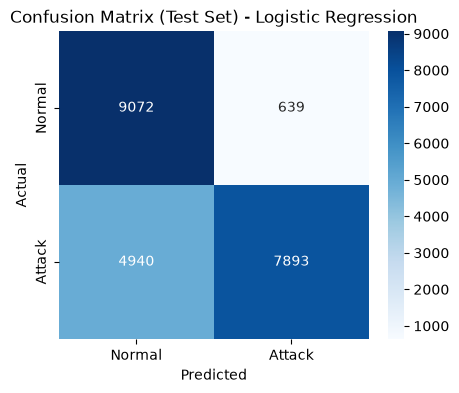


SVM — REAL TEST SET
Accuracy : 0.7821
Precision: 0.9753
Recall   : 0.6332
F1-Score : 0.7679


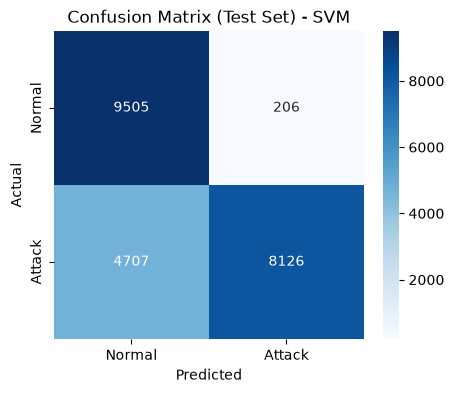


Random Forest — REAL TEST SET
Accuracy : 0.7774
Precision: 0.9668
Recall   : 0.6306
F1-Score : 0.7633


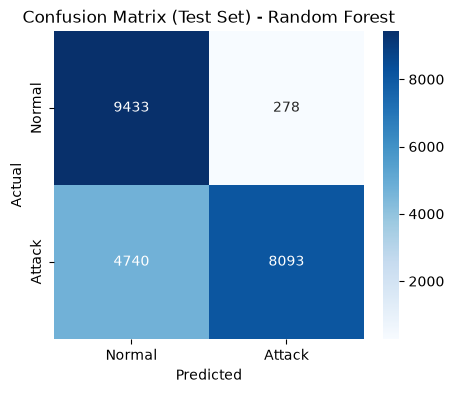


XGBoost — REAL TEST SET
Accuracy : 0.7953
Precision: 0.9687
Recall   : 0.6617
F1-Score : 0.7863


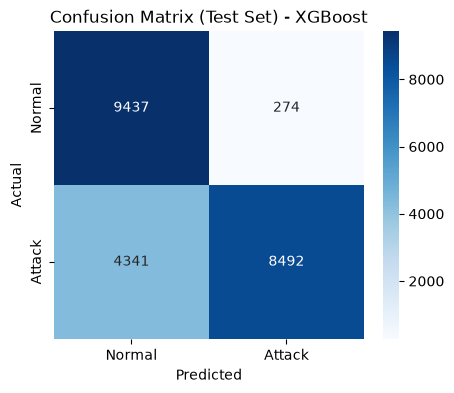


Final Model Comparison — REAL TEST SET:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.752528,0.925105,0.615055,0.738872
1,SVM,0.782071,0.975276,0.633211,0.767871
2,Random Forest,0.777413,0.966790,0.630640,0.763347
3,XGBoost,0.795289,0.968743,0.661731,0.786333


In [76]:
test_models = {
    "Logistic Regression": (lr_model, X_test_scaled),
    "SVM": (svm_model, X_test_scaled),
    "Random Forest": (rf_model, X_test),
    "XGBoost": (xgb_model, X_test),
}

test_results = []

for name, (model, X_data) in test_models.items():
    y_pred = model.predict(X_data)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    test_results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
    })

    print(f"\n{'='*50}\n{name} — REAL TEST SET\n{'='*50}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Attack"], yticklabels=["Normal", "Attack"])
    plt.title(f"Confusion Matrix (Test Set) - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

test_results_df = pd.DataFrame(test_results)
print("\nFinal Model Comparison — REAL TEST SET:")
display(test_results_df)


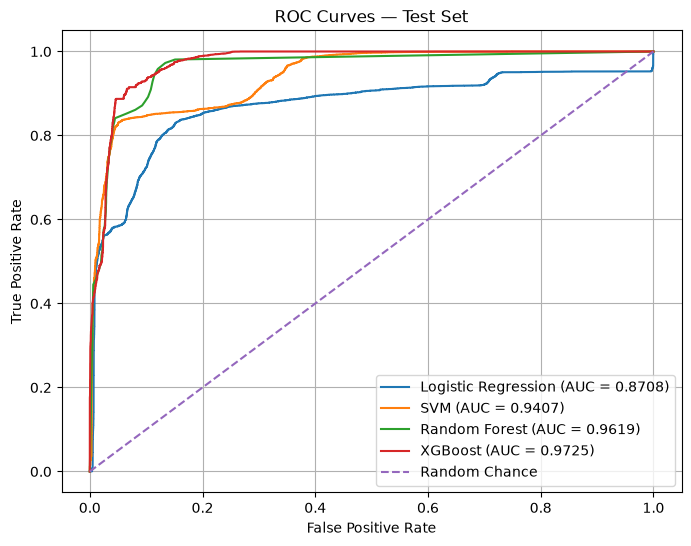

ROC-AUC Comparison — Test Set:


,Model,ROC-AUC
0,Logistic Regression,0.870803
1,SVM,0.940659
2,Random Forest,0.961923
3,XGBoost,0.972492


In [77]:
from sklearn.metrics import roc_auc_score, roc_curve

roc_results = []
plt.figure(figsize=(8, 6))

for name, (model, X_data) in test_models.items():
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_data)[:, 1]
    else:
        y_score = model.decision_function(X_data)

    auc = roc_auc_score(y_test, y_score)
    roc_results.append({"Model": name, "ROC-AUC": auc})

    fpr, tpr, _ = roc_curve(y_test, y_score)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Test Set")
plt.legend()
plt.grid()
plt.show()

roc_df = pd.DataFrame(roc_results)
print("ROC-AUC Comparison — Test Set:")
display(roc_df)


In [78]:
import os
import joblib

os.makedirs("../results", exist_ok=True)
os.makedirs("../models", exist_ok=True)

test_results_df.to_csv("../results/model_comparison_testset.csv", index=False)

best_model_name = test_results_df.sort_values("F1-Score", ascending=False).iloc[0]["Model"]
best_model = {"Logistic Regression": lr_model, "SVM": svm_model,
              "Random Forest": rf_model, "XGBoost": xgb_model}[best_model_name]

joblib.dump(best_model, f"../models/best_model_{best_model_name.replace(' ', '_').lower()}.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

print(f"Best model on test set: {best_model_name}")
print("Saved comparison table and best model.")

Best model on test set: XGBoost
Saved comparison table and best model.
